# Instrukcja - Transformacja Hougha

### Cel:
- zapoznanie z transformacją Hougha dla pojedynczego punktu,
- kilku punktów, prostych figur
- wykorzystanie transformacji Hougha do detekcji linii prostych na rzeczywistym obrazie
- transformacja Hougha w przestrzeni ab

### Transformacja Hough'a

Transformacja Hougha dla prostych jest metodą detekcji współliniowych punktów. Każda prosta może być jednoznacznie przedstawiona za pomocą dwóch parametrów. Przestrzeń tych parametrów to przestrzeń Hougha. Najczęściej wykorzystywanymi parametrami w tej metodzie są współczynniki ρ,θ

opisujące równanie prostej w postaci normalnej:

ρ=x⋅cos(θ)+y⋅sin(θ)

gdzie: ρ - promień wodzący, θ - kąt pomiędzy ρ a osią OX.

Własności transformacji Hougha:
- prostej w przestrzeni kartezjańskiej odpowiada punkt w przestrzeni Hougha
- pękowi prostych przechdzących przez punkt w przestrzeni kartezjańskiej odpowiada krzywa sinusoidalna w przestrzeni Hougha
- punkty leżące na tej samej prostej (w przestrzeni kartezjańskiej) korespondują z sinusoidami przechodzącymi przez wspólny punkt w przestrzeni Hougha.

Metoda wyliczania transformacji Hougha składa się z następujących kroków:
- przez każdy badany (różny od zera) punkt obrazu prowadzony jest pęk prostych, przechodzących przez ten punkt
- każda z tych prostych transformowana jest do przestrzeni Hougha i tworzy tam punkt o współrzędnych ρ,θ
- w ten sposób, każdy punkt obrazu pierwotnego (pęk prostych) jest odwzorowany w sinusoidalną krzywą w przestrzeni Hougha

Przestrzeń Hougha jest przestrzenią akumulacyjną tzn. punkty sinusoidalnych krzywych, wygenerowanych dla punktów obrazu pierwotnego dodają się w miejscach, w których krzywe te przecinają się. Powstałe w ten sposób (w przestrzeni Hougha) maksima odpowiadają zbiorom punktów, należących do jednej prostej. Współrzędne ρ,θ
tego maksimum jednoznacznie określają położenie prostej na obrazie pierwotnym.

### Transformacja Hougha dla małej liczby punktów.
   1. Uruchom poniższy kod. W tablicy `im` wskaż jeden punkt, dla którego ma zostać obliczona transformata.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

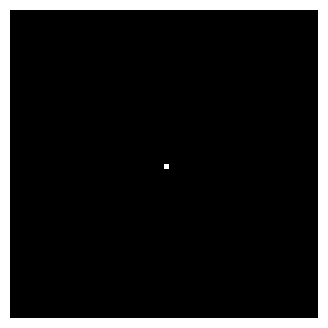

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage.transform import hough_line, hough_line_peaks
import os
import requests

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/11_Hough/'

images = []
fileNames = ["dom.png", "kwadraty.png", "lab112.png"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)
  image = cv2.imread(fileName)
  images.append(image)

def create_im(points: list[tuple[int, int]]):
  im = np.zeros((64,64), dtype=np.uint8)

  for (x, y) in points:
    im[x, y] = 1

  return im

im = create_im([(32, 32)])

fig, ax = plt.subplots()
fig.set_size_inches(4, 4)
ax.imshow(im, 'gray')
ax.axis('off')

3. Wykonaj transformację Hougha obazu im. Wykorzystaj funkcję *hough_line* z modułu _skimage.transform_. Funkcja zwraca: macierz H (przestrzeń Hougha) oraz dwa wektory theta i rho dla kolejnych 
4. Wyświetl przestrzeń Hougha za pomocą funkcji _plt.imshow_ (można też wykorzystać poniższą funkcję *show_hough*). Jak "wygląda" pojedynczy punkt w przestrzeni Hougha?

In [14]:
def show_hough(h, image):
    # Generating figure 1
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax = axes.ravel()

    ax[0].imshow(image, 'gray')
    ax[0].set_title('Input image')
    ax[0].set_axis_off()

    ax[1].imshow(h, 'hot')
    ax[1].set_title('Hough transform')
    ax[1].set_xlabel('Angles (degrees)')
    ax[1].set_ylabel('Distance (pixels)')
    ax[1].set_aspect('auto')
    
    plt.tight_layout()
    plt.show() 

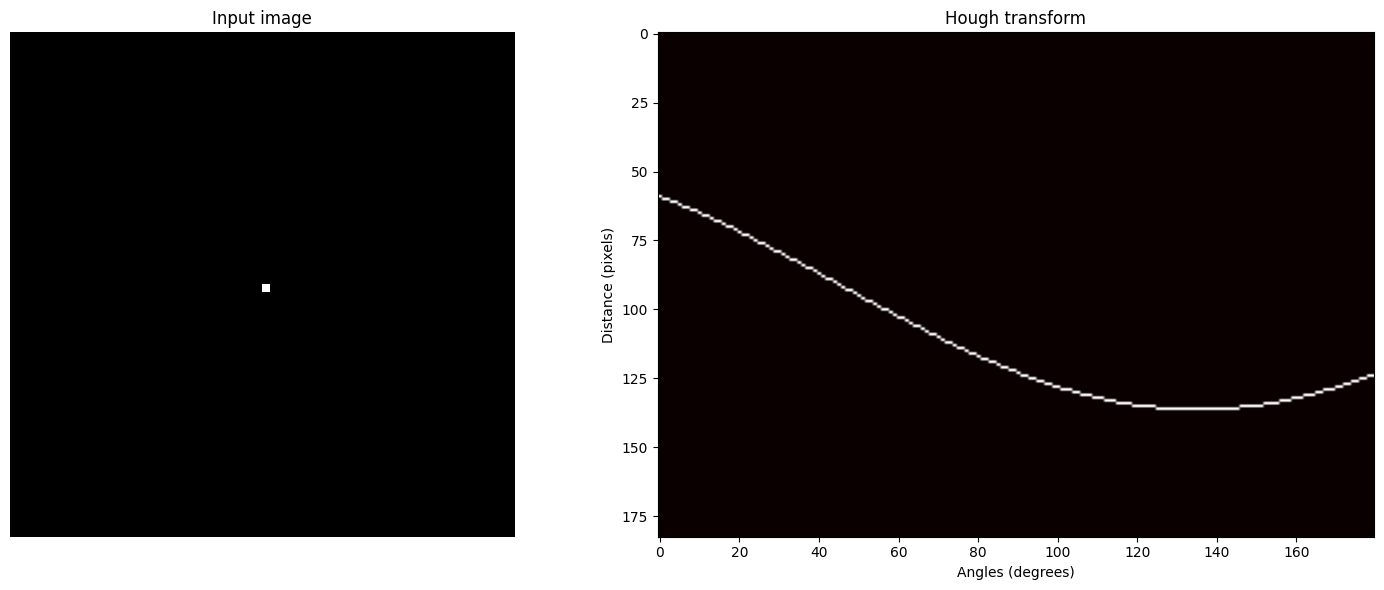

In [15]:
H_space, angles, distance = hough_line(im)
show_hough(H_space, im)

5. Powtórz punkty 1-4, ale tym razem klinkij dwa punkty. Jak zmienia się przestrzeń Hougha?
6. Powtórz punkty 1-4, ale tym razem kliknij kilka punktów starając się aby były współliniowe. Zaobserwuj zmiany w przestrzeni Hougha
7. Poeksperymentuj z różnymi układami punktów

(183, 180)


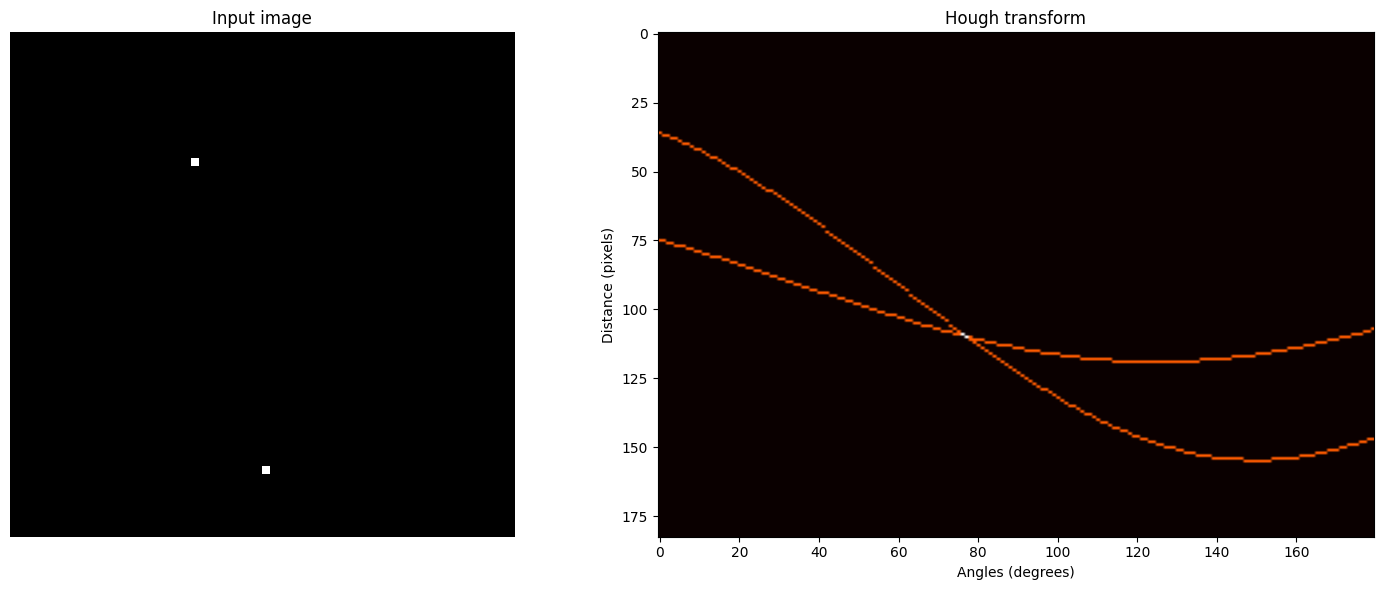

(183, 180)


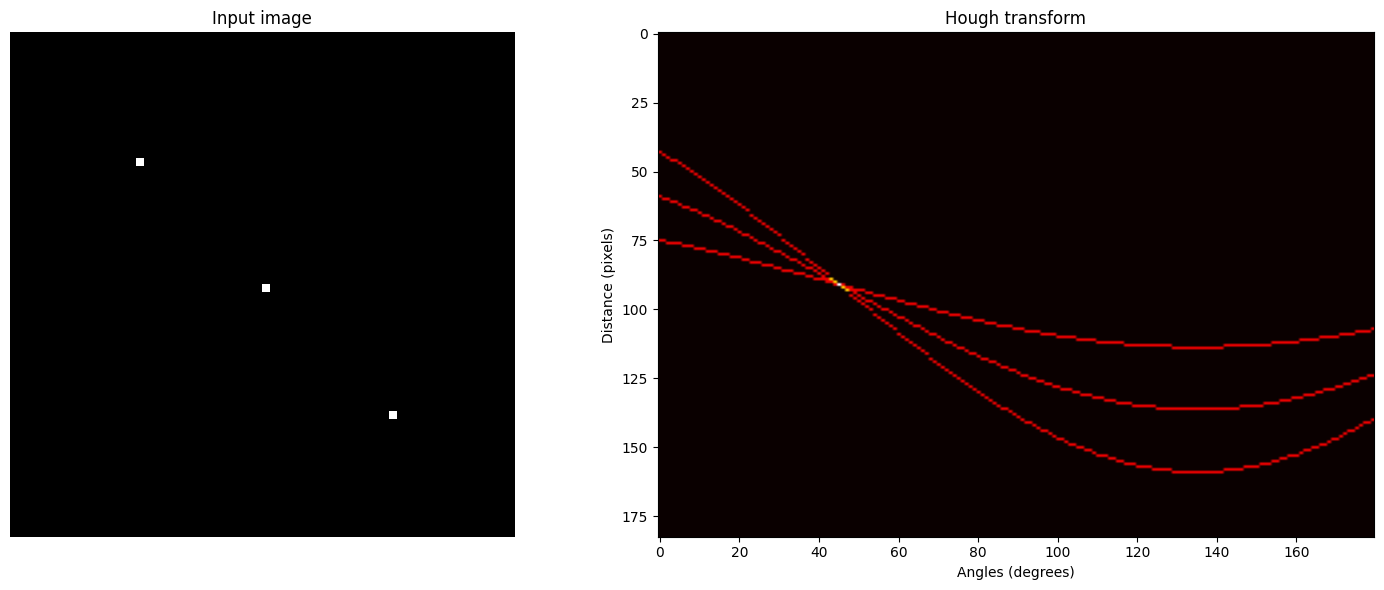

(183, 180)


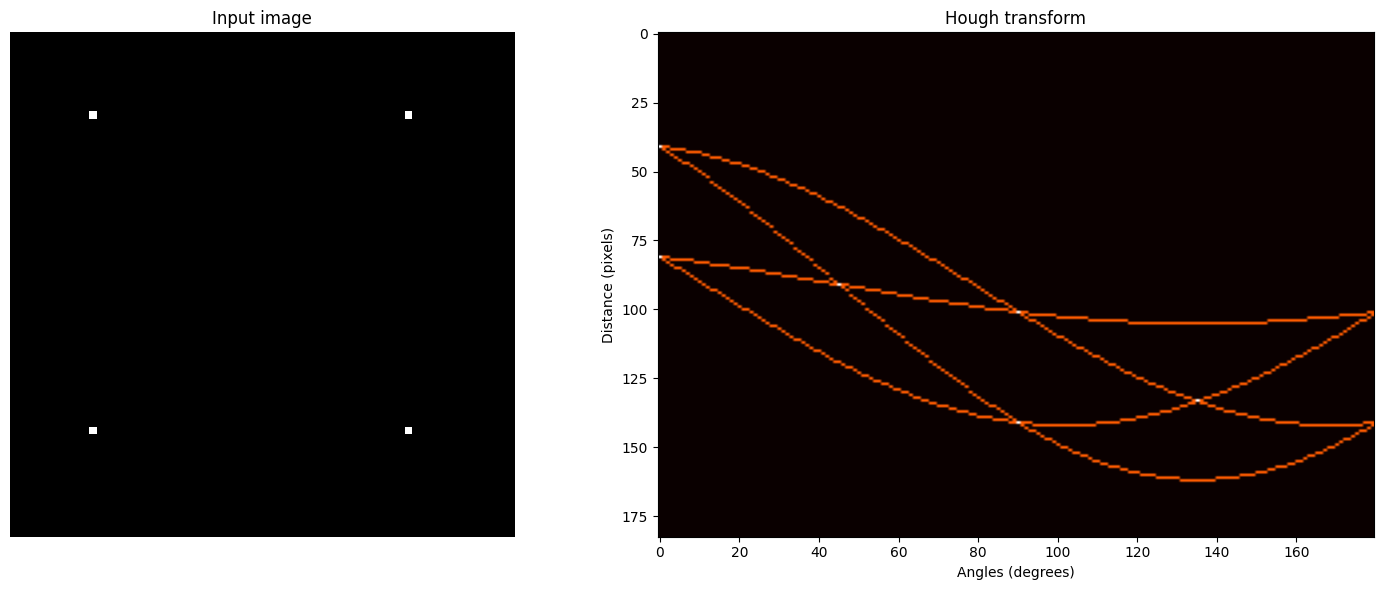

(183, 180)


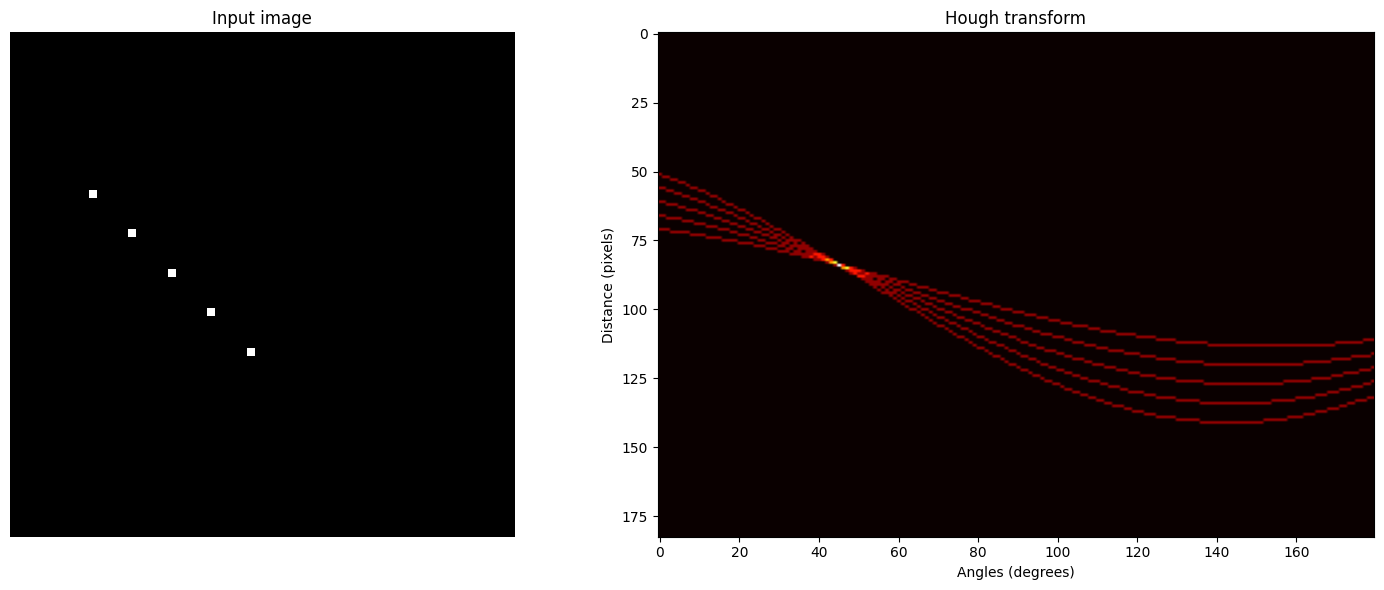

In [16]:
cases = [
    [(55, 32), (16, 23)],
    [(32, 32), (16, 16), (48, 48)],
    [(10, 10), (10, 50), (50, 10), (50, 50)],
    [(20, 10), (25, 15), (30, 20), (35, 25), (40, 30)]
]

for case in cases:
    im = create_im(case)
    H_space, angles, distance = hough_line(im)
    print(H_space.shape)
    show_hough(H_space, im)

### Transformata Hougha dla pojedynczego obiektu

W tym podpunkcie pokazane zostanie praktycznie wykorzystanie transformaty Hougha - do detekcji prostych na sztucznym rysunku.

   1. Wczytaj obraz "kwadraty.png". Wyświetl go.
   2. Wykonaj detekcję krawędzi jedną z metod gradientowych. Ważne aby obraz krawędzi był jak najlepszej jakości - co oznacza cienkie (nawet niekoniecznie ciągłe) krawędzie - dla tego przypadku nie powinno być trudne do uzyskania. Wyświetl obraz po detekcji krawędzi.
   3. Wykonaj transformatę Hougha obrazu krawędziowego. Wykorzystaj funkcję *hough\_line*.
   4. Wyświetl macierz H. Czy widoczna jest taka liczba maksimów jakiej się spodziewamy?

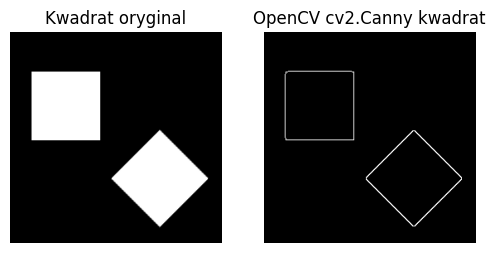

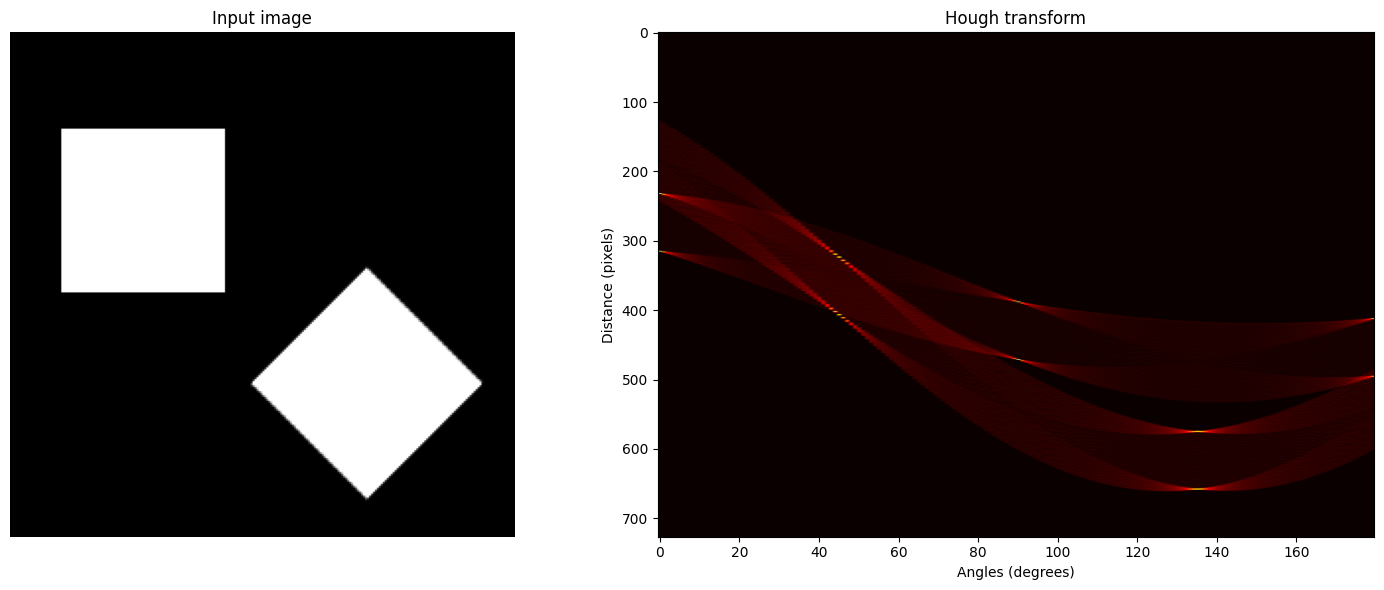

In [17]:
kwadrat = images[1]

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(kwadrat, 'gray')
axes[0].set_title("Kwadrat oryginal")
axes[0].axis("off")

def canny(image, thr_lower=30, thr_upper=90, sobel_size=3, size=5, sigma=1.4):
    blurred = cv2.GaussianBlur(image, (size, size), sigma)

    return cv2.Canny(blurred, thr_lower, thr_upper, None, apertureSize=sobel_size, L2gradient=True)

canny_opencv = canny(kwadrat)

axes[1].imshow(canny_opencv, cmap='gray')
axes[1].set_title('OpenCV cv2.Canny kwadrat')
axes[1].axis('off')
plt.show()

H_kwadrat, k_angles, k_directions = hough_line(canny_opencv)
show_hough(H_kwadrat, kwadrat)

 5. W module skimage.transform dostępna jest funkcja do automatycznej analizy przestrzeni Hougha - wyszukiwania maksimów - *hough\_line\_peaks*. Jako parametry przyjmuje ona wyniki funkcji *hough\_line* (macierz H, theta i rho). Dodatkowo można podać próg powyżej którego punkt uznawany jest za maksimum (_threshold_ - domyslnie jest to połowa maksimum w przestrzeni H) oraz liczbę poszukiwanych maksimów (*num_peaks*). Funkcja zwraca współrzędne maksimów. Wykorzystaj funkcję *hough\_line\_peaks* do znalezienia maksimów odpowiadających krawędziom kwadratów.
 6. Wyświetl macierz H używając konstrukcji:

In [18]:
accums, angles_peaks, dists_peaks = hough_line_peaks(
    H_kwadrat,
    k_angles,
    k_directions,
    threshold=0.5 * np.max(H_kwadrat),
    num_peaks=10
)

print(len(accums))

8


Taki zapis pozwoli na dołożenie annotacji (okręgów) w miejscach znalezionych maksimów. Wyrysowanie okręgu w punkcie x, y (o rozmiarze 10, w czerwonym kolorze, bez wypełnienia środka) realizuje wywołanie: 

**circle = plt.Circle((x, y), 10, color='r', fill=False)**

natomiast dołożenie takiego okręgu do obrazu to:

**ax.add_patch(circle)**

Zaznacz maksima na obrazie wykorzystując rezultat funkcji *hough\_line\_peaks* biorąc pod uwagę, że zwraca ona kąty w radianach z przedziału od -pi/2 do pi/2, a rho z przedziału od -r/2 do r/2 gdzie r to pionowy rozmiar przestrzeni Hougha. 

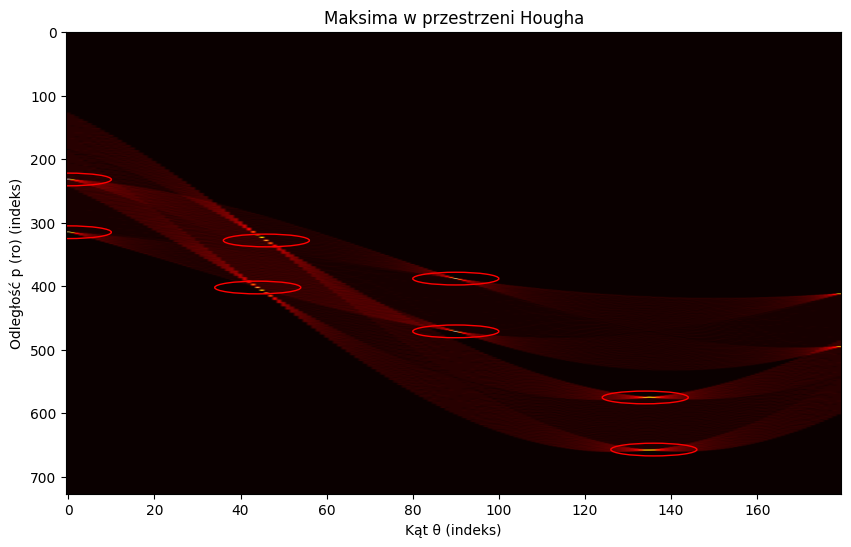

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(
    H_kwadrat,
    cmap='hot',
    aspect='auto'
)

for theta, rho in zip(angles_peaks, dists_peaks):
    x = np.argmin(np.abs(angles - theta))
    y = np.argmin(np.abs(k_directions - rho))
    
    circle = plt.Circle((x, y), 10, color='r', fill=False)
    ax.add_patch(circle)

ax.set_title("Maksima w przestrzeni Hougha")
ax.set_xlabel("Kąt θ (indeks)")
ax.set_ylabel("Odległość p (ro) (indeks)")
plt.show()


7. Istnieje też możliwość przeprowadzenia transformacji Hougha z użyciem biblioteki OpenCV. W bibliotece znajdują się dwie wersje funkcji wyszukującej linie proste - 'klasyczna' - _HoughLines_ oraz probabilistyczna _HoughLinesP_. Zadna z nich nie zwraca przestrzeni Hougha. Wynikiem działania pierwszej jest lista parametrów prostych (krotki zawierające rho, theta). Druga zwraca krotki 4-ro elementowe ze współrzędnymi końców odcinków wykorzystanych do wylicznia parametrów (czyli znalezienia prostej). 
8. Wyznacz linie obecne na obrazie za pomocą funkcji _HoughLines_. Wykryte linie wyrysuj na obrazie początkowym (UWAGA: wczytanym bez konwersji na graylevel). Do wyświetlania linii wykorzystaj przykładowy kod:

In [20]:
a = np.cos(theta)
b = np.sin(theta)
x0 = a*rho
y0 = b*rho
x1 = int(x0 + 1000*(-b))
y1 = int(y0 + 1000*(a))
x2 = int(x0 - 1000*(-b))
y2 = int(y0 - 1000*(a))  

Wykryto 8 linii w transformacie Hougha.


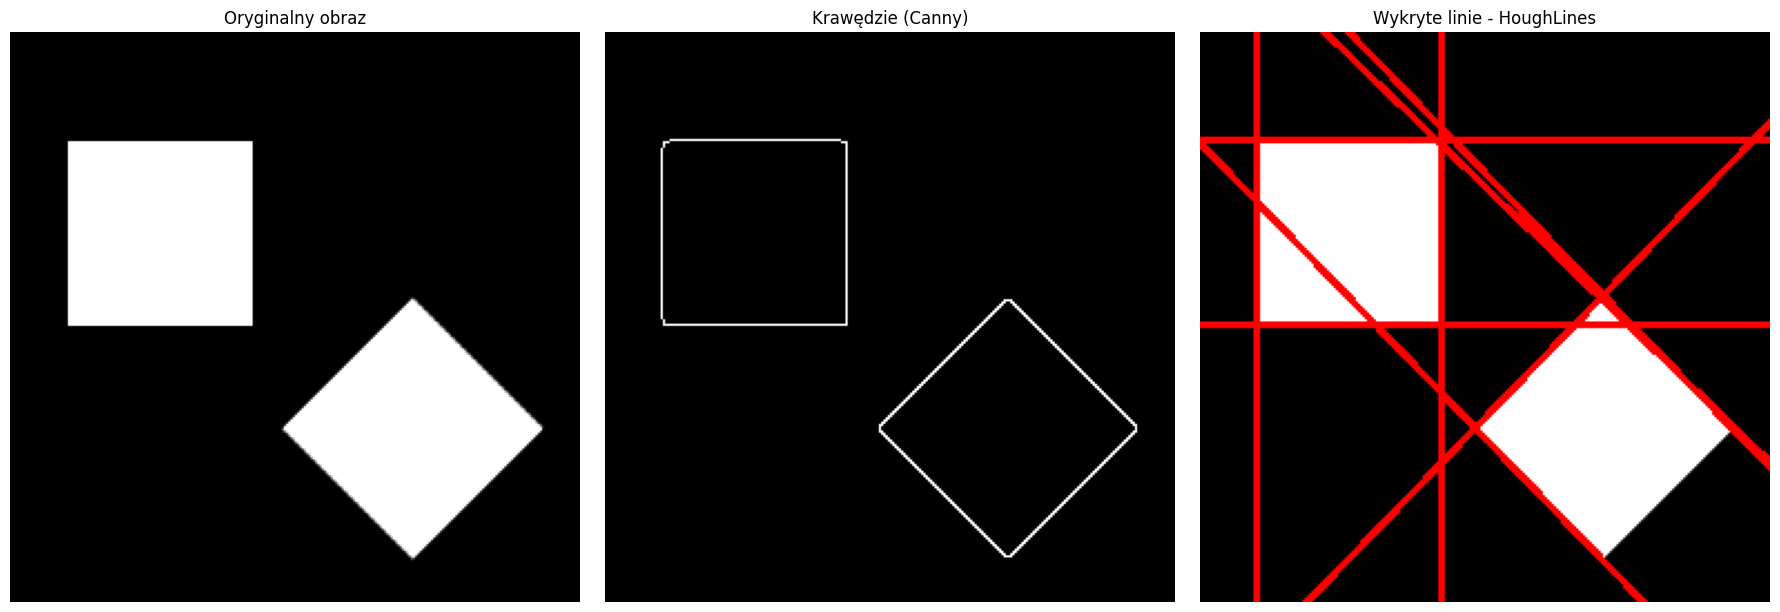

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

if len(kwadrat.shape) == 2:
    orig_img = cv2.cvtColor(kwadrat, cv2.COLOR_GRAY2BGR)
else:
    orig_img = kwadrat.copy()

threshold_hough = 65
lines = cv2.HoughLines(canny_opencv, rho=1, theta=np.pi/180, threshold=threshold_hough)

if lines is None:
    print("Nie wykryto żadnych linii")
else:
    print(f"Wykryto {len(lines)} linii w transformacie Hougha.")

output_img = orig_img.copy()

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(output_img, (x1, y1), (x2, y2), (0, 0, 255), 2) 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Oryginalny obraz')
axes[0].axis('off')

axes[1].imshow(canny_opencv, cmap='gray')
axes[1].set_title('Krawędzie (Canny)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axes[2].set_title('Wykryte linie - HoughLines')
axes[2].axis('off')

plt.tight_layout()
plt.show()

9. Wyznacz odcinki obecne na obrazie za pomocą funkcji _HoughLinesP_. Wykryte odcinki wyrysuj na obrazie początkowym (UWAGA: wczytanym bez konwersji na graylevel). 

Wykryto 10 odcinków Hougha.


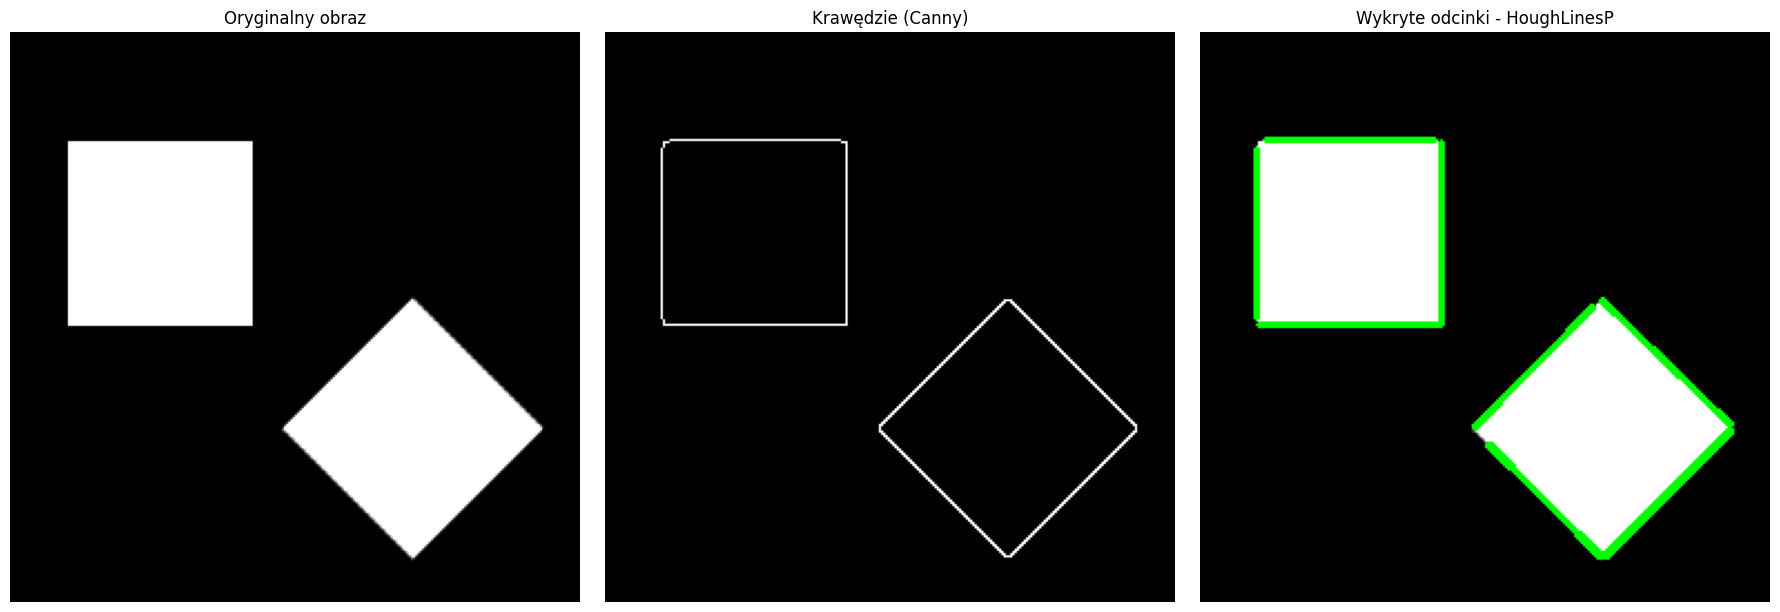

In [22]:
linesP = cv2.HoughLinesP(
    canny_opencv,
    rho=1,
    theta=np.pi/180,
    threshold=40,
    minLineLength=30,
    maxLineGap=5
)

if linesP is None:
    print("Nie wykryto żadnych odcinków!")
else:
    print(f"Wykryto {len(linesP)} odcinków Hougha.")

output_img = orig_img.copy()

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Oryginalny obraz')
axes[0].axis('off')

axes[1].imshow(canny_opencv, cmap='gray')
axes[1].set_title('Krawędzie (Canny)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axes[2].set_title('Wykryte odcinki - HoughLinesP')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Transformata Hougha dla obrazu rzeczywistego.

Bazując na kodzie stworzonym w punkcie B wyszukamy linie na obrazie rzeczywistym.
   1. Wczytaj obraz "lab112.png". Wyświetl go.
   2. Wykorzystując wszystkie poznane techniki przetwarzania obrazów (filtracja, przekształcenia morfologiczne, binaryzację, detekcję krawędzi) wyodrębnij krawędzie samych kwadratów - tak aby były jak najlepszej jakości (cienkie) - jednocześnie eliminując z obrazu zakłócenia.
   3. Wykorzystaj funkcje *hough_line* i *hough_line_peaks* do detekcji linii na obrazie, a następnie np. wykorzystując kod z punktu 8 poprzedniego ustępu wyrysuj na oryginalnym obrazie znalezione linie.

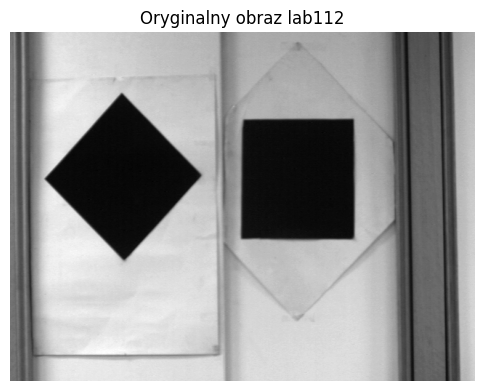

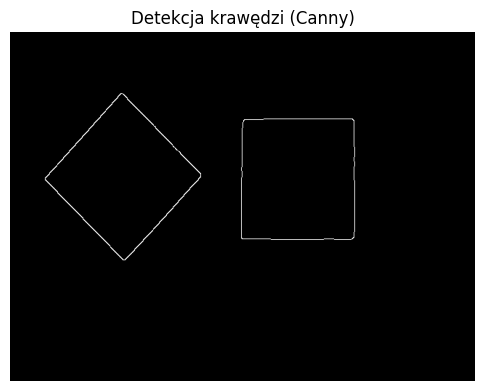

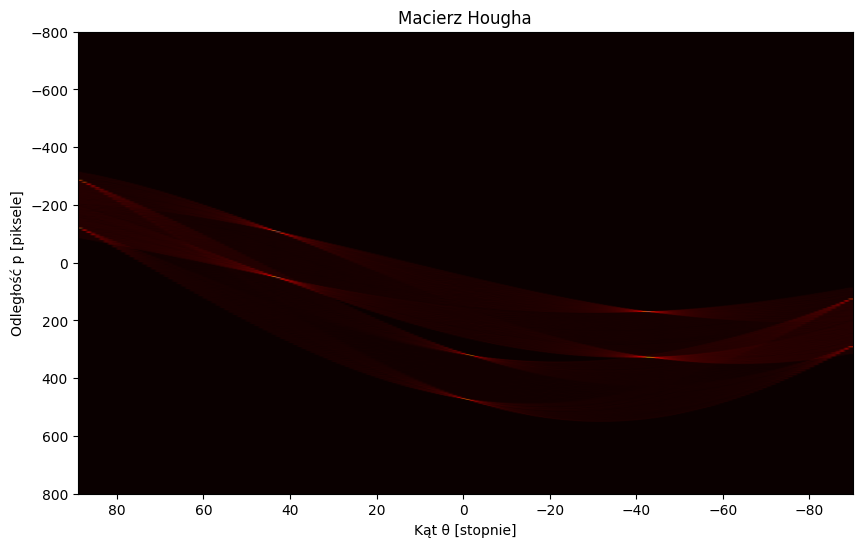

Znaleziono 8 linii maksymalnych


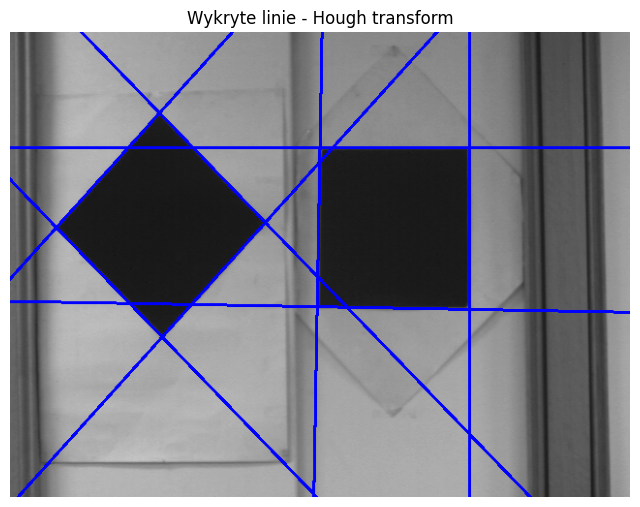

In [23]:
lab112 = images[2]

from skimage.transform import hough_line, hough_line_peaks
from skimage import io, color, filters, morphology
from skimage.morphology import footprint_rectangle

gray = cv2.cvtColor(lab112, cv2.COLOR_BGR2GRAY) / 255.0

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Oryginalny obraz lab112")
plt.axis('off')
plt.show()

edges = canny(lab112, thr_lower=50, thr_upper=170)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title("Detekcja krawędzi (Canny)")
plt.axis('off')
plt.show()

H, angles, dists = hough_line(edges)

plt.figure(figsize=(10,6))
plt.imshow(
    H,
    cmap='hot',
    aspect='auto',
    extent=[np.rad2deg(angles[-1]), np.rad2deg(angles[0]), dists[-1], dists[0]]
)
plt.xlabel('Kąt θ [stopnie]')
plt.ylabel('Odległość p [piksele]')
plt.title('Macierz Hougha')
plt.show()

accum, angles_peaks, dists_peaks = hough_line_peaks(H, angles, dists, num_peaks=20)

print(f"Znaleziono {len(angles_peaks)} linii maksymalnych")

if lab112.ndim == 2:
    output_img = cv2.cvtColor((lab112*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
else:
    output_img = lab112.copy()

for angle, dist in zip(angles_peaks, dists_peaks):
    a = np.cos(angle)
    b = np.sin(angle)
    x0 = a * dist
    y0 = b * dist
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(output_img, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Wykryte linie - Hough transform")
plt.axis('off')
plt.show()


4. Wczytaj obraz "dom.png". Wypróbuj działanie transformacji Hougha na tym obrazie z wykorzystaniem funkcji _cv2.HoughLinesP_  (oczywiście po odpowiednich przekształceniach). Postaraj się tak przygotować obraz z krawędziami i dobrać parametry aby wyrysować na oryginalnym obrazie odcinki obejmujące zarysy domu. Weź pod uwage dodatkowe parametry funkcji, takie jak:   minLineLength, maxLineGap.

Znaleziono 197 odcinków


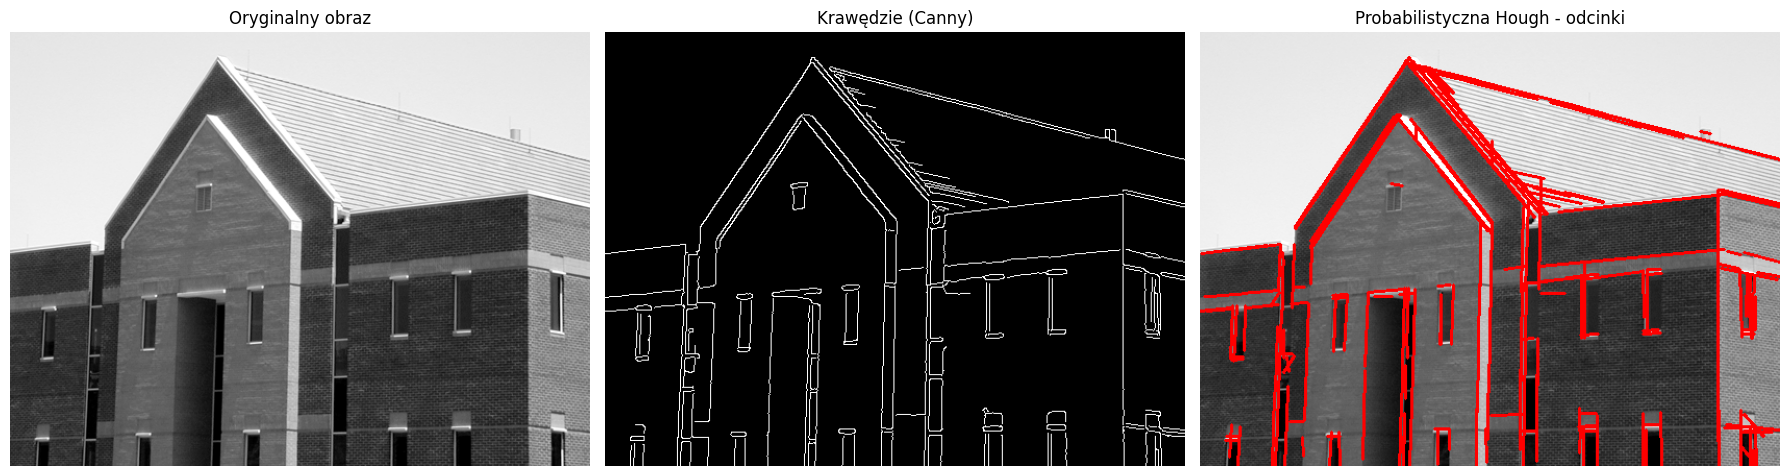

In [24]:
dom = images[0]
gray = cv2.cvtColor(dom, cv2.COLOR_BGR2GRAY)

edges = canny(dom)

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=20,
    minLineLength=10,
    maxLineGap=10
)

output_img = dom.copy()

if lines is not None:
    print(f"Znaleziono {len(lines)} odcinków")
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(output_img, (x1, y1), (x2, y2), color=(0, 0, 255), thickness=2)
else:
    print("Nie wykryto żadnych linii!")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(dom, cv2.COLOR_BGR2RGB))
axes[0].set_title("Oryginalny obraz")
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Krawędzie (Canny)")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axes[2].set_title("Probabilistyczna Hough - odcinki")
axes[2].axis('off')

plt.tight_layout()
plt.show()